<a href="https://colab.research.google.com/github/Frederque/EMSC2010_IndividualProject_Volcanoes-/blob/main/EMSC2010_IndividualProject_Volcanoes_Exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Volcano Erruption Correlation or Randomness**
---
###**Question:**
Are volcanic eruptions globally random events in time, or do they occur in statistically significant clusters?

###**Hypothesis:**
Volcanic eruptions are clustered in time, with erruptions occuring in statistically significant periods of increased or decreased activity rather than randomly through time.

###**Datasets used:**
**Dataset 1:**

Dataset Name: VCLocs (Volcano Locations)

Source Name: Smithsonian, Holocene Volcano List

Source: https://volcano.si.edu/volcanolist_holocene.cfm

**Dataset 2:**


Dataset Name: VCErruptions (Volcano Erruptions)

Source Name: Smithsonian, Confirmed Holocene Erruptions

Source: https://volcano.si.edu/search_eruption.cfm

###**Method:**

1.   **Data Preparation**
The VCLocs and VCErruptions datasets from the Smithsonian Institution Holocene Volcano database will be cleaned and filtered to extract eruption years. Duplicate entries and incomplete records will be removed, and all eruption events will be standardised into a single chronological list for analysis.

2.   **Time Series Construction**
Eruption data will be grouped by year to create a time series of eruption frequency. Line graphs will be produced to visualise eruption counts over time. Moving averages and rolling means will be applied to smooth short-term fluctuations and highlight long-term trends, including periods of increased activity or relative inactivity.

1.   **Randomised Erruption Simulation** Monte Carlo simulation will be used to test whether observed eruption patterns differ from randomness. Eruption years will be randomly redistributed across the same time period while keeping the total number of eruptions constant. This process will be repeated thousands of times to generate simulated “random Earth” eruption histories for comparison.

2.  **Statistical Comparison and Hypothesis Testing** The real eruption dataset will be compared against the simulated datasets. Statistics such as eruption frequency variance, cluster size, and inter-eruption intervals will be calculated for both real and simulated data. If the observed values fall outside the range expected from the simulations, this will provide evidence against the null hypothesis of randomness.



1.   **Correlation and Regression Analysis** Correlation analysis will be used to test whether eruption activity in one year is related to nearby years, indicating possible temporal dependence or clustering. Regression models will be applied to assess long-term trends in eruption frequency over time. Spurious correlations, underfitting, and overfitting will be considered to ensure that any identified patterns are statistically valid and not artefacts of the model.

2.   **Interpretation of Results** The results from time series analysis, Monte Carlo simulation, and correlation/regression will be combined to determine whether volcanic eruptions are best described as random events or temporally clustered processes. Conclusions will be based on whether observed patterns significantly deviate from random simulations and whether consistent temporal structure is detected across multiple statistical methods.

###**Course Content Applied:**

**Time Series Analysis(Week 10)**

Time series analysis will be used to study how volcanic eruptions change through time. Eruptions will be counted by year and plotted on line graphs to identify patterns in eruption frequency. Moving averages and rolling means will be used to smooth the data and highlight periods of high or low activity. The results will then be analysed to determine whether eruptions occur randomly or
in temporal clusters.

**Monte Carlo Techniques(Week 5)**
Monte Carlo techniques will be used to test whether volcanic eruptions occur randomly through time. The eruption years will be repeatedly randomised to create thousands of simulated datasets where eruptions occur purely by chance. The simulated results will then be compared with the real eruption record to determine whether the observed clustering is greater than expected from randomness alone.

**Correlation and Regression(Week 8)**
Correlation will be used to test whether eruption activity in one year is related to nearby years, indicating possible temporal clustering. Regression will be used to model long-term trends in eruption frequency over time. The analysis will also consider spurious correlations and model fit to ensure any detected patterns are statistically valid and not due to bias or overfitting.


###**AI Use Acknowledgement**
I utilised AI to plot the interactive globe, as I wanted a graphic that was more complex than what we completed in class. I set up the initial code and use AI to enhance it, I then read through to ensure that I understood all of the changes made.


## **Background Information**

*  Use a moving average, to try and find where peaks are.
*  Randomise years and do moving average again and see what kind of peaks you get when the data is random.
*   If in the real dataset youre seeing bigger peaks, it implies something more in clustering







## **Data Cleaning Information**

###**Why remove BCE Data?**

###**Changing time range**

###**Most Recent Erruption vs First Known Erruption**


### **Visually Plotting Volcanoes on Earth**


In [66]:
# Import packages
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# Read Headings to check columns have the right name. With the amount of changes I made to my dataset throughout this process, this was the easiest way to make sure my code is running the right dataset
df = pd.read_excel("VCLocsV2.xlsx")
print(df.head(0))

Empty DataFrame
Columns: [Volcano Name, Volcano Landform, Primary Volcano Type, Last Known Eruption, Latitude, Longitude, Elevation (m), Dominant Rock Type]
Index: []


In [67]:
# Constructing Figure 1 for Poster

# ============================================================
# LOAD DATA
# ============================================================

# Load without automatic headers
df = pd.read_excel(
    "VCLocsV2.xlsx",
    header=None
)

# Use first row as headers
df.columns = df.iloc[0]

# Remove header row from data
df = df[1:]

# Clean column names
df.columns = df.columns.str.strip()

# ============================================================
# KEEP REQUIRED COLUMNS
# ============================================================

df = df[[
    "Primary Volcano Type",
    "Latitude",
    "Longitude",
    "Volcano Landform",
    "Elevation (m)",
    "Dominant Rock Type",
    "Last Known Eruption"
]]

# ============================================================
# CLEAN DATA
# ============================================================

# Convert coordinates to numeric
df["Latitude"] = pd.to_numeric(
    df["Latitude"],
    errors="coerce"
)

df["Longitude"] = pd.to_numeric(
    df["Longitude"],
    errors="coerce"
)

# Convert elevation
df["Elevation (m)"] = pd.to_numeric(
    df["Elevation (m)"],
    errors="coerce"
)

# Remove invalid coordinates
df = df.dropna(subset=["Latitude", "Longitude"])

# ============================================================
# COLOUR MAPS
# ============================================================

volcano_types = df["Primary Volcano Type"].unique()

volcano_colours = {
    v: px.colors.qualitative.Dark24[i % 24]
    for i, v in enumerate(volcano_types)
}

# ============================================================
# CREATE FIGURE
# ============================================================

fig = go.Figure()

# ============================================================
# ADD VOLCANOES
# ============================================================

for vtype in volcano_types:

    subset = df[df["Primary Volcano Type"] == vtype]

    fig.add_trace(
        go.Scattergeo(

            lon=subset["Longitude"],
            lat=subset["Latitude"],

            mode="markers",

            marker=dict(
                size=8,
                color=volcano_colours[vtype],
                opacity=0.8
            ),

            # ====================================================
            # HOVER INFORMATION
            # ====================================================

            text=[
                f"""
                <b>Primary Volcano Type:</b> {vt}<br>
                <b>Volcano Landform:</b> {landform}<br>
                <b>Last Known Eruption:</b> {eruption}<br>
                <b>Latitude:</b> {lat}<br>
                <b>Longitude:</b> {lon}<br>
                <b>Elevation (m):</b> {elev}<br>
                <b>Dominant Rock Type:</b> {rock}
                """
                for vt, landform, eruption, lat, lon, elev, rock in zip(
                    subset["Primary Volcano Type"],
                    subset["Volcano Landform"],
                    subset["Last Known Eruption"],
                    subset["Latitude"],
                    subset["Longitude"],
                    subset["Elevation (m)"],
                    subset["Dominant Rock Type"]
                )
            ],

            hoverinfo="text",

            name=vtype
        )
    )

# ============================================================
# LAYOUT
# ============================================================

fig.update_layout(

    title="Global Volcano Erruptions, 8300BCE - 2026 AD (Figure 1)",

    height=850,

    geo=dict(

        projection_type="equirectangular",

        showland=True,
        landcolor="rgb(220,220,220)",

        showocean=True,
        oceancolor="rgb(180,210,255)",

        showcountries=True,
        countrycolor="gray",

        showcoastlines=True,
        coastlinecolor="black",

        showframe=False
    ),

    legend=dict(
        title="Primary Volcano Type"
    )
)

# ============================================================
# SHOW MAP
# ============================================================

fig.show()

##**Plotting Volcanic Erruptions and Looking For Correlation**

How can we Plot volcanoes to measure correlation/causation with erruptions?


1.   Plotting on the earth
1.   Making Graphs
2.  Plotting Volcanoes per year





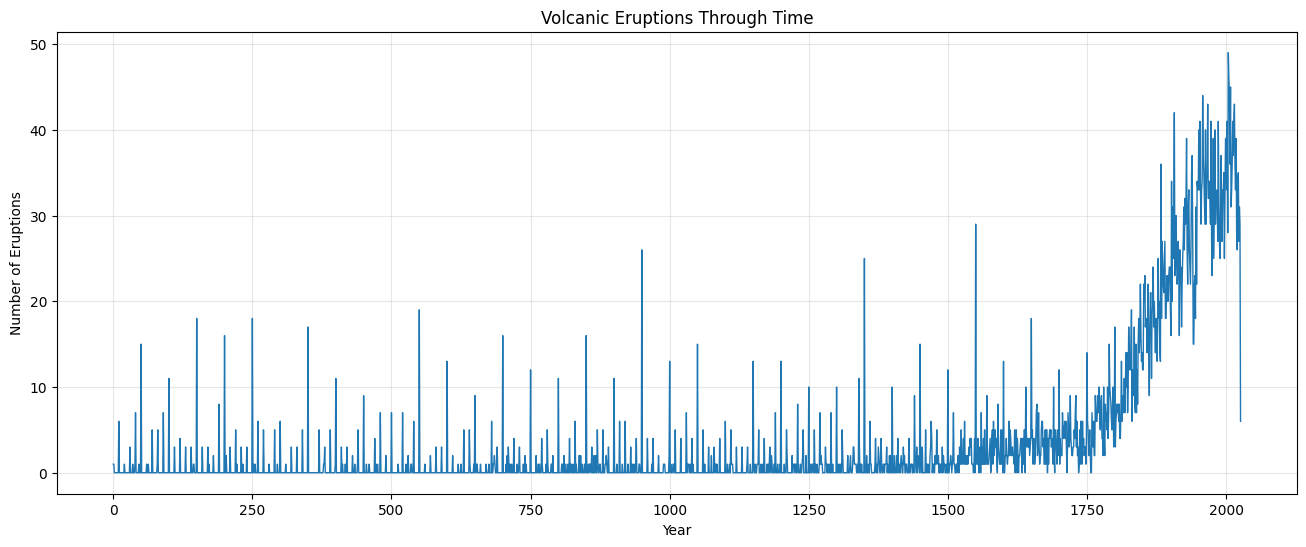

In [ ]:
#First Plot: A general Plot of increase (n) of volcano Erruptions overtime

#Loading/Importing Dataset
df = pd.read_excel("VCErruptionsV2.xlsx")

# Cleaning Data and Converting years into numerical values

def convert_year(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    # BCE years → negative
    if "BCE" in value:
        num = re.findall(r"\d+", value)
        return -int(num[0]) if num else None

    # CE years → positive
    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    # Plain numeric years
    if value.isdigit():
        return int(value)

    return None

# Apply conversion
df["Year"] = df["Start Year"].apply(convert_year)

# Remove Missing Years. Originally, I had this line to get rid of the volcanoes without years. However, I realised it woudl be better jus tot do this in my original dataset, as that would make it better in general too

#Count Erruptions-per-year to work out total increase overtime per-year

year_counts = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

# CREATE FULL TIME SERIES

years = range(
    df_clean["Year"].min(),
    df_clean["Year"].max() + 1
)

counts = [
    year_counts.get(year, 0)
    for year in years
]

# Plotting Figure 2

plt.figure(figsize=(16,6))

plt.plot(
    years,
    counts,
    linewidth=1
)

plt.title("Volcanic Eruptions Through Time (Figure 2)")

plt.xlabel("Year")

plt.ylabel("Number of Eruptions")

plt.grid(alpha=0.3)

plt.show()

In [62]:
#Plotting Figure 3: A shortened version of Figure 2, to only include data from 1950-2026

#Cutting down time
modern_years = range(1950, 2027)

modern_counts = [
    year_counts.get(year, 0)
    for year in modern_years
]

axes[1].plot(
    modern_years,
    modern_counts,
    linewidth=1
)

#Plotting
axes[1].set_title(
    "Volcanic Eruptions Through Time (1950–2026)"
)

axes[1].set_xlabel("Year")

axes[1].set_ylabel("Number of Eruptions")

axes[1].grid(alpha=0.3)

plt.show()


/tmp/ipykernel_30510/3351027707.py:7: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



NameError: name 'axes' is not defined



### **Visually Plotting Volcanoes on Earth**

In [10]:
# Import packages
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

In [14]:
# Read Headings to check columns have the right name. With the amount of changes I made to my dataset throughout this process, this was the easiest way to make sure my code is running the right dataset
df = pd.read_excel("VCLocsV2.xlsx")
print(df.head(0))

Empty DataFrame
Columns: [Volcano Name, Volcano Landform, Primary Volcano Type, Last Known Eruption, Latitude, Longitude, Elevation (m), Dominant Rock Type]
Index: []


In [27]:
# Constructing Figure 1 for Poster

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ============================================================
# LOAD DATA
# ============================================================

# Load without automatic headers
df = pd.read_excel(
    "VCLocsV2.xlsx",
    header=None
)

# Use first row as headers
df.columns = df.iloc[0]

# Remove header row from data
df = df[1:]

# Clean column names
df.columns = df.columns.str.strip()

# ============================================================
# KEEP REQUIRED COLUMNS
# ============================================================

df = df[[
    "Primary Volcano Type",
    "Latitude",
    "Longitude",
    "Volcano Landform",
    "Elevation (m)",
    "Dominant Rock Type",
    "Last Known Eruption"
]]

# ============================================================
# CLEAN DATA
# ============================================================

# Convert coordinates to numeric
df["Latitude"] = pd.to_numeric(
    df["Latitude"],
    errors="coerce"
)

df["Longitude"] = pd.to_numeric(
    df["Longitude"],
    errors="coerce"
)

# Convert elevation
df["Elevation (m)"] = pd.to_numeric(
    df["Elevation (m)"],
    errors="coerce"
)

# Remove invalid coordinates
df = df.dropna(subset=["Latitude", "Longitude"])

# ============================================================
# COLOUR MAPS
# ============================================================

volcano_types = df["Primary Volcano Type"].unique()

volcano_colours = {
    v: px.colors.qualitative.Dark24[i % 24]
    for i, v in enumerate(volcano_types)
}

# ============================================================
# CREATE FIGURE
# ============================================================

fig = go.Figure()

# ============================================================
# ADD VOLCANOES
# ============================================================

for vtype in volcano_types:

    subset = df[df["Primary Volcano Type"] == vtype]

    fig.add_trace(
        go.Scattergeo(

            lon=subset["Longitude"],
            lat=subset["Latitude"],

            mode="markers",

            marker=dict(
                size=8,
                color=volcano_colours[vtype],
                opacity=0.8
            ),

            # ====================================================
            # HOVER INFORMATION
            # ====================================================

            text=[
                f"""
                <b>Primary Volcano Type:</b> {vt}<br>
                <b>Volcano Landform:</b> {landform}<br>
                <b>Last Known Eruption:</b> {eruption}<br>
                <b>Latitude:</b> {lat}<br>
                <b>Longitude:</b> {lon}<br>
                <b>Elevation (m):</b> {elev}<br>
                <b>Dominant Rock Type:</b> {rock}
                """
                for vt, landform, eruption, lat, lon, elev, rock in zip(
                    subset["Primary Volcano Type"],
                    subset["Volcano Landform"],
                    subset["Last Known Eruption"],
                    subset["Latitude"],
                    subset["Longitude"],
                    subset["Elevation (m)"],
                    subset["Dominant Rock Type"]
                )
            ],

            hoverinfo="text",

            name=vtype
        )
    )

# ============================================================
# LAYOUT
# ============================================================

fig.update_layout(

    title="Global Volcano Erruptions, 8300BCE - 2026 AD (Figure 1)",

    height=850,

    geo=dict(

        projection_type="equirectangular",

        showland=True,
        landcolor="rgb(220,220,220)",

        showocean=True,
        oceancolor="rgb(180,210,255)",

        showcountries=True,
        countrycolor="gray",

        showcoastlines=True,
        coastlinecolor="black",

        showframe=False
    ),

    legend=dict(
        title="Primary Volcano Type"
    )
)

# ============================================================
# SHOW MAP
# ============================================================

fig.show()

**Interpreting Global Volcano Spread From Figure 1**

##Plotting Volcanic Erruptions by year (Broken)


In [29]:
# ============================================================
# INTERACTIVE GLOBAL VOLCANO MAP WITH YEAR SLIDER
# ============================================================

import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# ============================================================
# LOAD DATA
# ============================================================

# Load volcano locations data (for types and tectonic settings)
df_locs = pd.read_excel("VCLocs.xls", header=1)
df_locs.columns = df_locs.columns.str.strip()
df_locs = df_locs[
    [
        "Volcano Number", # Assuming this is a common key for merging
        "Primary Volcano Type",
        "Tectonic Setting"
    ]
]
# Drop rows where essential merge keys or classification data are missing
df_locs = df_locs.dropna(subset=["Volcano Number", "Primary Volcano Type", "Tectonic Setting"])
df_locs["Volcano Number"] = df_locs["Volcano Number"].astype(int) # Ensure consistent type for merge

# Load volcano eruptions data
df_eruptions = pd.read_excel("VCErruptions.xlsx", header=5)
df_eruptions.columns = df_eruptions.columns.str.strip()
df_eruptions = df_eruptions[
    [
        "Volcano Number",
        "Start Year",
        "Latitude",
        "Longitude"
    ]
]
# Drop rows where essential eruption data is missing
df_eruptions = df_eruptions.dropna(subset=["Volcano Number", "Start Year", "Latitude", "Longitude"])
df_eruptions["Volcano Number"] = df_eruptions["Volcano Number"].astype(int) # Ensure consistent type for merge

# Merge the two dataframes. We want all eruption events, with their corresponding volcano metadata.
# Using a left merge from eruptions to locations ensures all eruptions are kept.
df = pd.merge(df_eruptions, df_locs, on="Volcano Number", how="left")

# ============================================================
# CLEAN YEAR DATA
# ============================================================

# Convert eruption year to numeric
df["Year"] = pd.to_numeric(
    df["Start Year"],
    errors="coerce"
)

# Remove rows without valid year or if Primary Volcano Type/Tectonic Setting is missing after merge
# (this means some eruptions might not have corresponding type/setting in VCLocs)
df = df.dropna(subset=["Year", "Primary Volcano Type", "Tectonic Setting"])

# Ensure there are actually years to process
if df.empty:
    print("No valid eruption data found after cleaning and merging. Cannot create animation.")
    fig = go.Figure()
    fig.update_layout(title="No Eruption Data Available")
    fig.show()
    exit() # Exit the cell execution to prevent further errors

df["Year"] = df["Year"].astype(int)

# Sort the DataFrame by year to ensure correct animation order
df = df.sort_values(by="Year").reset_index(drop=True)

# ============================================================
# COLOUR MAPS
# ============================================================

volcano_types = df["Primary Volcano Type"].unique()

volcano_colours = {
    v: px.colors.qualitative.Dark24[i % 24]
    for i, v in enumerate(volcano_types)
}

tectonic_settings = df["Tectonic Setting"].unique()

outline_colours = {
    t: px.colors.qualitative.Set1[i % 9]
    for i, t in enumerate(tectonic_settings)
}

# ============================================================
# CREATE FIGURE
# ============================================================

fig = go.Figure()

# ============================================================
# CREATE YEAR FRAMES
# ============================================================

years = sorted(df["Year"].unique())

frames = []

for year in years:

    yearly_df = df[df["Year"] == year]

    frame_data = []

    # --------------------------------------------------------
    # CASE: NO ERUPTIONS
    # --------------------------------------------------------

    if len(yearly_df) == 0:

        frame_data.append(

            go.Scattergeo(
                lon=[],
                lat=[],
                mode="markers",
                showlegend=False
            )
        )

    # --------------------------------------------------------
    # PLOT VOLCANOES
    # --------------------------------------------------------

    else:

        for vtype in volcano_types:

            subset = yearly_df[
                yearly_df["Primary Volcano Type"] == vtype
            ]

            if len(subset) == 0:
                continue

            outline_list = [
                outline_colours[t]
                for t in subset["Tectonic Setting"]
            ]

            frame_data.append(

                go.Scattergeo(

                    lon=subset["Longitude"],
                    lat=subset["Latitude"],

                    mode="markers",

                    marker=dict(
                        size=8,
                        color=volcano_colours[vtype],

                        line=dict(
                            width=2,
                            color=outline_list
                        ),

                        opacity=0.85
                    ),

                    text=[
                        f"""
                        Volcano Type: {vt}<br>
                        Tectonic Setting: {ts}<br>
                        Year: {yr}<br>
                        Latitude: {lat}<br>
                        Longitude: {lon}
                        """
                        for vt, ts, yr, lat, lon in zip(
                            subset["Primary Volcano Type"],
                            subset["Tectonic Setting"],
                            subset["Year"],
                            subset["Latitude"],
                            subset["Longitude"]
                        )
                    ],

                    hoverinfo="text",

                    name=vtype
                )
            )

    frames.append(
        go.Frame(
            data=frame_data,
            name=str(year)
        )
    )

fig.frames = frames

# ============================================================
# INITIAL DATA
# ============================================================

initial_year = years[0]
initial_df = df[df["Year"] == initial_year]

for vtype in volcano_types:

    subset = initial_df[
        initial_df["Primary Volcano Type"] == vtype
    ]

    if len(subset) == 0:
        continue

    outline_list = [
        outline_colours[t]
        for t in subset["Tectonic Setting"]
    ]

    fig.add_trace(

        go.Scattergeo(

            lon=subset["Longitude"],
            lat=subset["Latitude"],

            mode="markers",

            marker=dict(
                size=8,

                color=volcano_colours[vtype],

                line=dict(
                    width=2,
                    color=outline_list
                ),

                opacity=0.85
            ),

            text=[
                f"""
                Volcano Type: {vt}<br>
                Tectonic Setting: {ts}<br>
                Year: {yr}<br>
                Latitude: {lat}<br>
                Longitude: {lon}
                """
                for vt, ts, yr, lat, lon in zip(
                    subset["Primary Volcano Type"],
                    subset["Tectonic Setting"],
                    subset["Year"],
                    subset["Latitude"],
                    subset["Longitude"]
                )
            ],

            hoverinfo="text",

            name=vtype
        )
    )

# ============================================================
# SLIDER
# ============================================================

sliders = [
    {
        "active": 0,
        "currentvalue": {
            "prefix": "Year: "
        },
        "pad": {"t": 50},
        "steps": [
            {
                "args": [
                    [str(year)],
                    {
                        "frame": {"duration": 0, "redraw": True},
                        "mode": "immediate"
                    }
                ],
                "label": str(year),
                "method": "animate"
            }
            for year in years
        ]
    }
]

# ============================================================
# LAYOUT
# ============================================================

fig.update_layout(

    title="Global Volcanoes by Eruption Year",

    height=900,

    sliders=sliders,

    geo=dict(

        projection_type="orthographic",

        showland=True,
        landcolor="rgb(220,220,220)",

        showocean=True,
        oceancolor="rgb(180,210,255)",

        showcountries=True,
        countrycolor="gray",

        showcoastlines=True,
        coastlinecolor="black",

        showframe=False
    ),

    legend=dict(
        title="Volcano Type"
    ),

    annotations=[
        dict(
            text="If no volcanoes appear, no eruptions are recorded for that year.",
            x=0.5,
            y=0.02,
            xref="paper",
            yref="paper",
            showarrow=False,
            font=dict(size=14)
        )
    ]
)

# ============================================================
# SHOW FIGURE
# ============================================================

fig.show()

# Optional save
# fig.write_html("interactive_volcano_slider_map.html")

KeyError: "None of [Index(['Volcano Number', 'Primary Volcano Type', 'Tectonic Setting'], dtype='object')] are in the [columns]"

In [ ]:
import pandas as pd

# Read the Excel file without a header to inspect its content
df_raw_eruptions = pd.read_excel("VCErruptions.xlsx", header=None)

# Display the first few rows to identify the actual header row
print(df_raw_eruptions.head(10))

##**Finding Erruption Correlation**

In [49]:
# Printing the top row of column names to make sure the correct dataset is being used
df = pd.read_excel('VCErruptionsV2.xlsx')
print(df.head(0))

Empty DataFrame
Columns: [Volcano Name, Start Year]
Index: []


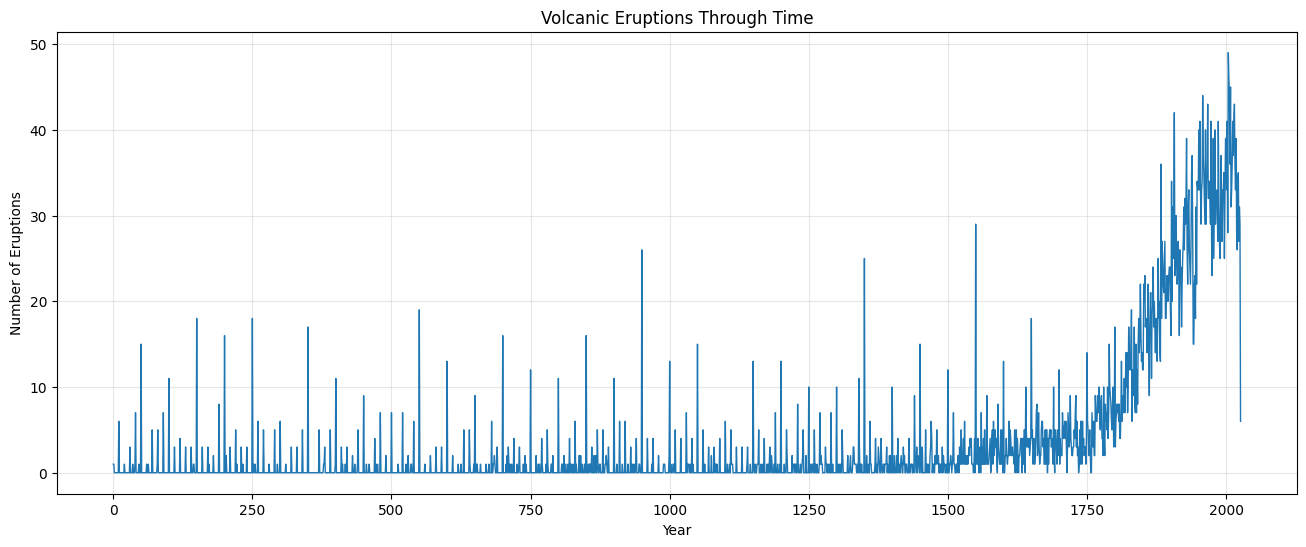

In [58]:
#First Plot: A general Plot of increase (n) of volcano Erruptions overtime

#Loading/Importing Dataset
df = pd.read_excel("VCErruptionsV2.xlsx")

# Cleaning Data and Converting years into numerical values

def convert_year(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    # BCE years → negative
    if "BCE" in value:
        num = re.findall(r"\d+", value)
        return -int(num[0]) if num else None

    # CE years → positive
    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    # Plain numeric years
    if value.isdigit():
        return int(value)

    return None

# Apply conversion
df["Year"] = df["Start Year"].apply(convert_year)

# Remove Missing Years. Originally, I had this line to get rid of the volcanoes without years. However, I realised it woudl be better jus tot do this in my original dataset, as that would make it better in general too

#Count Erruptions-per-year to work out total increase overtime per-year

year_counts = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

# CREATE FULL TIME SERIES

years = range(
    df_clean["Year"].min(),
    df_clean["Year"].max() + 1
)

counts = [
    year_counts.get(year, 0)
    for year in years
]

# PLOT

plt.figure(figsize=(16,6))

plt.plot(
    years,
    counts,
    linewidth=1
)

plt.title("Volcanic Eruptions Through Time")

plt.xlabel("Year")

plt.ylabel("Number of Eruptions")

plt.grid(alpha=0.3)

plt.show()

####Explaining and Interpreting the Erruption Increase in 2026

The increase in 2026 is not a real spike in volcanic activity but a consequence of how the dataset records ongoing eruptions. For volcanoes that remain active over multiple years, the “Last Known Eruption” field is often updated to the most recent observation year, meaning many long-duration or persistently active volcanoes are assigned the current year (2026 CE). As a result, eruptions that have been occurring or intermittently active over time all get grouped into the same final year rather than being distributed across their actual eruption timeline. This creates an artificial concentration of values in the most recent year and inflates the apparent number of eruptions in 2026, even though it mainly reflects reporting and updating conventions rather than a genuine increase in volcanic activity.

#### Ways we can prevent this from impacting our data

1.  Remove 2026 values entirely if they are being used as a placeholder for ongoing activity rather than a true eruption year, which prevents artificial clustering.
2. Treat these entries separately by distinguishing between historical eruptions and ongoing or recently active volcanoes, rather than combining them in the same dataset.
1.   Improve accuracy by using full eruption histories instead of just the “last known eruption” field
2.   Group data into larger time intervals, such as decades, which reduces noise and smooths out reporting artefacts

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import re

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_excel('VCLocs.xls', header=1)
y = df['Last Known Eruption']

# ------------------------------------------------------------
# CLEAN FUNCTION
# ------------------------------------------------------------
def convert_year(value):
    if pd.isna(value):
        return None

    value = str(value).strip()

    if value == "Unknown":
        return None

    # Convert CE only (drop BCE entirely)
    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    return None  # BCE removed

df["Year"] = y.apply(convert_year)

# keep only valid years
df_clean = df.dropna(subset=["Year"])

# ------------------------------------------------------------
# FILTER: 0 CE → present
# ------------------------------------------------------------
df_clean = df_clean[(df_clean["Year"] >= 0) & (df_clean["Year"] <= 2026)]

# ------------------------------------------------------------
# METHOD 1: REMOVE 2026
# ------------------------------------------------------------
df_no_2026 = df_clean[df_clean["Year"] != 2026]

# ------------------------------------------------------------
# METHOD 2: SEPARATE ONGOING (2026 ONLY)
# ------------------------------------------------------------
df_ongoing = df_clean[df_clean["Year"] == 2026]
df_historical = df_clean[df_clean["Year"] != 2026]

# ------------------------------------------------------------
# METHOD 3: DECADE BINNING (0–2026 only)
# ------------------------------------------------------------
df_decade = df_clean.copy()
df_decade["Decade"] = (df_decade["Year"] // 10) * 10
decade_counts = df_decade["Decade"].value_counts().sort_index()

# ------------------------------------------------------------
# METHOD 4: CAP 2026 → 2025
# ------------------------------------------------------------
df_capped = df_clean.copy()
df_capped["Year"] = df_capped["Year"].replace(2026, 2025)

# ------------------------------------------------------------
# METHOD 5: MOVING AVERAGE
# ------------------------------------------------------------
year_counts_raw = df_clean["Year"].value_counts().sort_index()

years = range(0, 2027)
counts_raw = [year_counts_raw.get(y, 0) for y in years]
rolling_avg = pd.Series(counts_raw).rolling(window=10).mean()

# ------------------------------------------------------------
# PLOTTING FUNCTION
# ------------------------------------------------------------
def plot_data(title, years, counts):
    plt.figure(figsize=(12,4))
    plt.plot(years, counts)
    plt.title(title)
    plt.xlabel("Year (CE)")
    plt.ylabel("Eruptions")
    plt.grid(alpha=0.3)
    plt.show()

# ------------------------------------------------------------
# METHOD 1
# ------------------------------------------------------------
counts1 = df_no_2026["Year"].value_counts().sort_index()
plot_data(
    "Method 1: Remove 2026 (0–2026 CE)",
    years,
    [counts1.get(y, 0) for y in years]
)

# ------------------------------------------------------------
# METHOD 2
# ------------------------------------------------------------
counts2 = df_historical["Year"].value_counts().sort_index()
plot_data(
    "Method 2: Exclude Ongoing (0–2026 CE)",
    years,
    [counts2.get(y, 0) for y in years]
)

# ------------------------------------------------------------
# METHOD 3
# ------------------------------------------------------------
plt.figure(figsize=(12,4))
plt.bar(decade_counts.index, decade_counts.values, width=8)
plt.title("Method 3: Decade Binning (0–2026 CE)")
plt.xlabel("Decade")
plt.ylabel("Eruptions")
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# METHOD 4
# ------------------------------------------------------------
counts4 = df_capped["Year"].value_counts().sort_index()
plot_data(
    "Method 4: Cap 2026 → 2025 (0–2026 CE)",
    years,
    [counts4.get(y, 0) for y in years]
)

# ------------------------------------------------------------
# METHOD 5
# ------------------------------------------------------------
plt.figure(figsize=(12,4))
plt.plot(years, rolling_avg)
plt.title("Method 5: 10-Year Moving Average (0–2026 CE)")
plt.xlabel("Year")
plt.ylabel("Smoothed Eruptions")
plt.grid(alpha=0.3)
plt.show()

### **Time Series Analysis (Week 10)**
Time series analysis will be used to study how volcanic eruptions change through time. Eruptions will be counted by year and plotted on line graphs to identify patterns in eruption frequency. Moving averages and rolling means will be used to smooth the data and highlight periods of high or low activity. The results will then be analysed to determine whether eruptions occur randomly or  in temporal clusters.



In [ ]:
# Time Series Analysis of Global Volcanic Eruptions
# Improved Trend Line Fit

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Load Dataset
# -----------------------------

df = pd.read_excel("VCErrupt.xlsx")

# -----------------------------
# Extract Eruption Years
# -----------------------------

years = pd.to_numeric(df["Start Year"], errors="coerce")

years = years.dropna().astype(int)

# -----------------------------
# Count Eruptions Per Year
# -----------------------------

eruption_counts = years.value_counts().sort_index()

time_series = pd.DataFrame({
    "Year": eruption_counts.index,
    "Eruptions": eruption_counts.values
})

# -----------------------------
# Polynomial Trend Line
# -----------------------------

# Higher degree polynomial for better fit
degree = 12

z = np.polyfit(
    time_series["Year"],
    time_series["Eruptions"],
    degree
)

p = np.poly1d(z)

trendline = p(time_series["Year"])

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(14,6))

# Raw eruption counts
plt.plot(
    time_series["Year"],
    time_series["Eruptions"],
    linewidth=1,
    label="Eruptions Per Year"
)

# Improved trend line
plt.plot(
    time_series["Year"],
    trendline,
    linewidth=4,
    label=f"Polynomial Trend Line (Degree {degree})"
)

# Labels
plt.xlabel("Year")
plt.ylabel("Number of Eruptions")
plt.title("Global Volcanic Eruptions Through Time")

plt.legend()
plt.grid()

plt.show()

Compare to a moving average
show that theres a b9ais in the data towards detection

take data from 1950 onwards and plot a 0 order polynomiAL. Is it consistent with 0 order overtime, or a 1st order where the posterior of the gradient is 0. WOuld also imply flatness. Where does flatness start. plot over 30 year intervals, moving regeression overtime.

In [ ]:
# Time Series Analysis of Global Volcanic Eruptions
# 1750–Present

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Load Dataset
# -----------------------------

df = pd.read_excel("VCErrupt1950.xlsx")

# -----------------------------
# Extract Eruption Years
# -----------------------------

years = pd.to_numeric(df["Start Year"], errors="coerce")

years = years.dropna().astype(int)

# -----------------------------
# Count Eruptions Per Year
# -----------------------------

eruption_counts = years.value_counts().sort_index()

time_series = pd.DataFrame({
    "Year": eruption_counts.index,
    "Eruptions": eruption_counts.values
})

# -----------------------------
# Polynomial Trend Line
# -----------------------------

degree = 9

z = np.polyfit(
    time_series["Year"],
    time_series["Eruptions"],
    degree
)

p = np.poly1d(z)

trendline = p(time_series["Year"])

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(14,6))

# Eruption counts
plt.plot(
    time_series["Year"],
    time_series["Eruptions"],
    linewidth=1,
    label="Eruptions Per Year"
)

# Trend line
plt.plot(
    time_series["Year"],
    trendline,
    linewidth=4,
    label=f"Polynomial Trend Line (Degree {degree})"
)

# Axis limits
plt.xlim(1950, time_series["Year"].max())

# Labels
plt.xlabel("Year")
plt.ylabel("Number of Eruptions")
plt.title("Global Volcanic Eruptions Through Time (1750–Present)")

plt.legend()
plt.grid()

plt.show()

In [ ]:
# ============================================================
# VOLCANIC ERUPTION TIME SERIES ANALYSIS
# 1950–Present
# Moving 30-Year Regression Analysis
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_excel("VCErrupt1950.xlsx")

# ============================================================
# EXTRACT YEARS
# ============================================================

years = pd.to_numeric(df["Start Year"], errors="coerce")

years = years.dropna().astype(int)

# Only use 1950 onwards
years = years[years >= 1950]

# ============================================================
# COUNT ERUPTIONS PER YEAR
# ============================================================

eruption_counts = years.value_counts().sort_index()

time_series = pd.DataFrame({
    "Year": eruption_counts.index,
    "Eruptions": eruption_counts.values
})

# Fill missing years with 0 eruptions
all_years = pd.DataFrame({
    "Year": np.arange(1950, years.max() + 1)
})

time_series = all_years.merge(
    time_series,
    on="Year",
    how="left"
)

time_series["Eruptions"] = (
    time_series["Eruptions"]
    .fillna(0)
)

# ============================================================
# MOVING 30-YEAR REGRESSION
# ============================================================

window = 30

slopes = []
midpoints = []

for start in range(0, len(time_series) - window):

    subset = time_series.iloc[start:start+window]

    x = subset["Year"]
    y = subset["Eruptions"]

    # Linear regression
    slope, intercept, r, p, stderr = linregress(x, y)

    slopes.append(slope)

    # midpoint year of window
    midpoints.append(subset["Year"].mean())

# ============================================================
# PLOT 1: ERUPTIONS THROUGH TIME
# ============================================================

plt.figure(figsize=(14,6))

plt.plot(
    time_series["Year"],
    time_series["Eruptions"],
    linewidth=1
)

plt.xlabel("Year")
plt.ylabel("Number of Eruptions")
plt.title("Global Volcanic Eruptions Per Year (1950–Present)")

plt.grid()

plt.show()

# ============================================================
# PLOT 2: MOVING REGRESSION SLOPE
# ============================================================

plt.figure(figsize=(14,6))

plt.plot(
    midpoints,
    slopes,
    linewidth=3,
    label="30-Year Regression Slope"
)

# Flatness line
plt.axhline(
    0,
    linestyle="--",
    linewidth=2,
    label="Zero Slope (Flat Trend)"
)

plt.xlabel("Central Year of 30-Year Window")
plt.ylabel("Regression Slope")
plt.title("Moving 30-Year Regression of Eruption Frequency")

plt.legend()
plt.grid()

plt.show()

# ============================================================
# PRINT INTERPRETATION
# ============================================================

mean_slope = np.mean(slopes)

print("Average slope:", round(mean_slope, 4))

if abs(mean_slope) < 0.01:
    print("Overall eruption frequency is approximately flat (0th order).")

else:
    print("Overall eruption frequency shows a long-term trend.")